In [ ]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(cowplot)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(msigdbr)
library(tidyverse)
library(ggpubr)
library(rstatix)
library(ggprism)
library(reshape2)
library(Seurat)
library(ggplot2)
library(cowplot)
library(tidyverse)
library(dplyr)
library(Seurat)
library(ggplot2)
library(patchwork)
library(ggsci)
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)
library(scCustomize)
library(ggplot2)
library(ggforce)
library(dplyr)
library(ggrepel)
library(patchwork)
library(ggpubr)
library(export)
library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)
library(factoextra)  
library(corrplot)   
library(pheatmap)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)  
library(GSEABase)    
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)##

In [2]:
setwd("。/04fig3/")

In [3]:
sp <- readRDS("。/merge_red.RDS")

In [65]:
###pseubulk
###lets do it
dout <- "./00pseudubulk/"

In [66]:
area

[1] "GCL"         "Optic nerve" "Cornea&conj" "INL"         "Len"        
 [6] "ONL"         "Iris"        "CB"          "Muscle"      "RPE"

In [245]:
se <- CreateSeuratObject(counts = exp2,meta.data = mm)

In [246]:
se <- NormalizeData(se)

Normalizing layer: counts



In [247]:
ex <- as.data.frame(se@assays$RNA$data)


In [248]:
Idents(se) <- as.factor(se@meta.data$group)

In [249]:
deg <- FindAllMarkers(se)

Calculating cluster RIR

Calculating cluster Sham



In [3]:
####gs
######GO KEGG
####let us find something
####GSVA genesets
genesets <- msigdbr(species = "Mus musculus", category = "C5")#msigdbr导入基因集
genesets <- subset(genesets, select = c("gs_name","gene_symbol")) %>% as.data.frame()#as data.frame
genesets$gs_name <- str_replace(genesets$gs_name,"GOBP_","")
head(genesets)
genesets$gs_name <- gsub("_", " ", genesets$gs_name)
genesets$gs_name <- tolower(substring(genesets$gs_name, 1))
# genesets <- split(genesets$gene_symbol, genesets$gs_name)#
head(genesets)

,gs_name,gene_symbol
,<chr>,<chr>
1,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Aasdhppt
2,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Aldh1l1
3,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Aldh1l2
4,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Mthfd1
5,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Mthfd1l
6,10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS,Mthfd2l


,gs_name,gene_symbol
,<chr>,<chr>
1,10 formyltetrahydrofolate metabolic process,Aasdhppt
2,10 formyltetrahydrofolate metabolic process,Aldh1l1
3,10 formyltetrahydrofolate metabolic process,Aldh1l2
4,10 formyltetrahydrofolate metabolic process,Mthfd1
5,10 formyltetrahydrofolate metabolic process,Mthfd1l
6,10 formyltetrahydrofolate metabolic process,Mthfd2l


In [4]:
genesets1 <- msigdbr(species = "Mus musculus", category = "C2")#msigdbr导入基因集
genesets1 <- subset(genesets1, select = c("gs_name","gene_symbol")) %>% as.data.frame()#as data.frame
genesets1$gs_name <- str_replace(genesets1$gs_name,"KEGG_","")
head(genesets1)
genesets1$gs_name <- gsub("_", " ", genesets1$gs_name)
genesets1$gs_name <- tolower(substring(genesets1$gs_name, 1))
# genesets <- split(genesets$gene_symbol, genesets$gs_name)#
genesets1$gs_name <- paste0("C2 ",genesets1$gs_name)
head(genesets1)

,gs_name,gene_symbol
,<chr>,<chr>
1,ABBUD_LIF_SIGNALING_1_DN,Ahnak
2,ABBUD_LIF_SIGNALING_1_DN,Alcam
3,ABBUD_LIF_SIGNALING_1_DN,Ankrd40
4,ABBUD_LIF_SIGNALING_1_DN,Arid1a
5,ABBUD_LIF_SIGNALING_1_DN,Bckdhb
6,ABBUD_LIF_SIGNALING_1_DN,AU021092


,gs_name,gene_symbol
,<chr>,<chr>
1,C2 abbud lif signaling 1 dn,Ahnak
2,C2 abbud lif signaling 1 dn,Alcam
3,C2 abbud lif signaling 1 dn,Ankrd40
4,C2 abbud lif signaling 1 dn,Arid1a
5,C2 abbud lif signaling 1 dn,Bckdhb
6,C2 abbud lif signaling 1 dn,AU021092


In [7]:
genesets <- rbind(genesets1,genesets)

In [8]:
grep("microglia",unique(genesets$gs_name),value = TRUE)

[1] "C2 wp microglia pathogen phagocytosis pathway"    
 [2] "C2 wp tyrobp causal network in microglia"         
 [3] "microglial cell activation"                       
 [4] "microglial cell mediated cytotoxicity"            
 [5] "microglial cell migration"                        
 [6] "microglial cell proliferation"                    
 [7] "microglia differentiation"                        
 [8] "negative regulation of microglial cell activation"
 [9] "positive regulation of microglial cell activation"
[10] "regulation of microglial cell activation"

In [5]:
gg <- c("microglial cell migration","inflammatory response")
gss <- genesets[which(genesets$gs_name%in%gg),]

In [7]:
write.csv(gss,"gsss.csv")

In [ ]:
gs <- split(gss$gene_symbol, gss$gs_name)
head(gs)

In [136]:
for(i in unique(gss$gs_name)){
    sp <- AddModuleScore(sp,list(gss[which(gss$gs_name==i),]$gene_symbol),slot = "scale.data")
    colnames(sp@meta.data) <- str_replace(colnames(sp@meta.data),"Cluster1",i)
}

In [137]:
coord.df = data.frame(x=sp@meta.data$x, y=sp@meta.data$y, stringsAsFactors=FALSE)
rownames(coord.df) = rownames(sp@meta.data)

sp@images$image = new(
    Class = 'SlideSeq',
    assay = "RNA",
    key = "image",
    coordinates = coord.df)

In [83]:
for(i in unique(sp@meta.data$chip)){
    sp1 <- subset(sp,subset=chip==i)
}

In [139]:
sp1 <- subset(sp,subset=chip=="SS200000340TRD1")
sp2 <- subset(sp,subset=chip=="Y40217P4")

In [95]:

library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(ggprism)

In [153]:
k=0
for(key in area){
    sc <- subset(sp,subset=area==key)
    n=0
    for(i in unique(sc@meta.data$sample)){
        n=n+1
        pbmc <- subset(sc,subset=sample==i)
        counts <- data.frame(rowSums(as.matrix(pbmc@assays$RNA$counts)))
        colnames(counts) <- paste0(i,"_",key)
        m <- as.data.frame(paste0(i,"_",key))
        colnames(m) <- "names"
        m$sample <- i
        m$area <- key
        if(n==1){
            counts1 <- counts
            m1 <- m
        }
        else{
            counts1 <- merge(counts1,counts,all=TRUE,by=0)
            rownames(counts1) <- counts1$Row.names
            counts1 <- counts1[,-1]
            m1 <- rbind(m1,m)
        }
    }
    k=k+1
    if(k==1){
        counts2 <- counts1
        m2 <- m1
    }
    else{
        counts2 <- merge(counts2,counts1,all=TRUE,by=0)
        rownames(counts2) <- counts2$Row.names
        counts2 <- counts2[,-1]
        m2 <- rbind(m2,m1)
    }
}

In [168]:
m <- as.data.frame(unique(sp@meta.data$sample))
rownames(m) <- m[,1]
colnames(m) <- "group"
m$group <- substr(m$group,1,3)
m$batch <- c("1","1","1","1","2","2","2","2","2","2","2")
m$group <- str_replace(m$group,"Sha","Sham")
m$sample <- rownames(m)
m

,group,batch,sample
,<chr>,<chr>,<chr>
Sham2,Sham,1,Sham2
Sham1,Sham,1,Sham1
RIR2,RIR,1,RIR2
RIR1,RIR,1,RIR1
RIR3,RIR,2,RIR3
Sham4,Sham,2,Sham4
RIR4,RIR,2,RIR4
RIR5,RIR,2,RIR5
Sham5,Sham,2,Sham5


In [169]:
m2$group <- substr(m2$names,1,3)
m2$group <- str_replace(m2$group,"Sha","Sham")
m2$batch <- "NA"
for(i in unique(m$sample)){
    m2[which(m2$sample==i),]$batch <- m[which(m$sample==i),]$batch
}

In [171]:
bulk <- CreateSeuratObject(counts = counts2,meta.data = m2)

In [172]:
bulk <- NormalizeData(bulk,normalization.method = "LogNormalize",scale.factor = 10000000)

Normalizing layer: counts



In [173]:
bulk

An object of class Seurat 
24382 features across 100 samples within 1 assay 
Active assay: RNA (24382 features, 0 variable features)
 2 layers present: counts, data

In [175]:
exp <- as.data.frame(bulk@assays$RNA$data)

In [180]:
gsvapar <- gsvaParam(as.matrix(exp), gs)
gsva_es <- gsva(gsvapar)

ℹ GSVA version 2.0.4

! 253 genes with constant values throughout the samples

! Genes with constant values are discarded

ℹ Calculating GSVA ranks

ℹ kcdf='auto' (default)

ℹ GSVA dense (classical) algorithm

ℹ Row-wise ECDF estimation with Gaussian kernels

ℹ Calculating GSVA column ranks

! Duplicated gene IDs removed from gene set inflammatory response

ℹ Calculating GSVA scores

✔ Calculations finished



In [186]:
rownames(m2) <- m2$names

In [ ]:
mer <- merge(m2,t(gsva_es),all=TRUE,by=0)
head(mer)
mer$area <- factor(mer$area,levels = area)

In [330]:
mytheme <-theme_prism()+theme(strip.text=element_text(size=16),axis.line=element_line(color="black",linewidth=0.4),
      axis.text.y=element_text(color="black",size=16),
      axis.text.x=element_text(color="black",size=15,angle=45),
      axis.title=element_text(color="black",size=18),
      panel.grid.minor=element_blank(),
      panel.grid.major=element_line(size=0.2,color="#e5e5e5"),
      legend.position="none")

In [288]:
mer$area <- factor(mer$area,levels = c("GCL","Optic nerve","Iris","CB","RPE",'Len','Cornea&conj','INL',"Muscle",'ONL'))

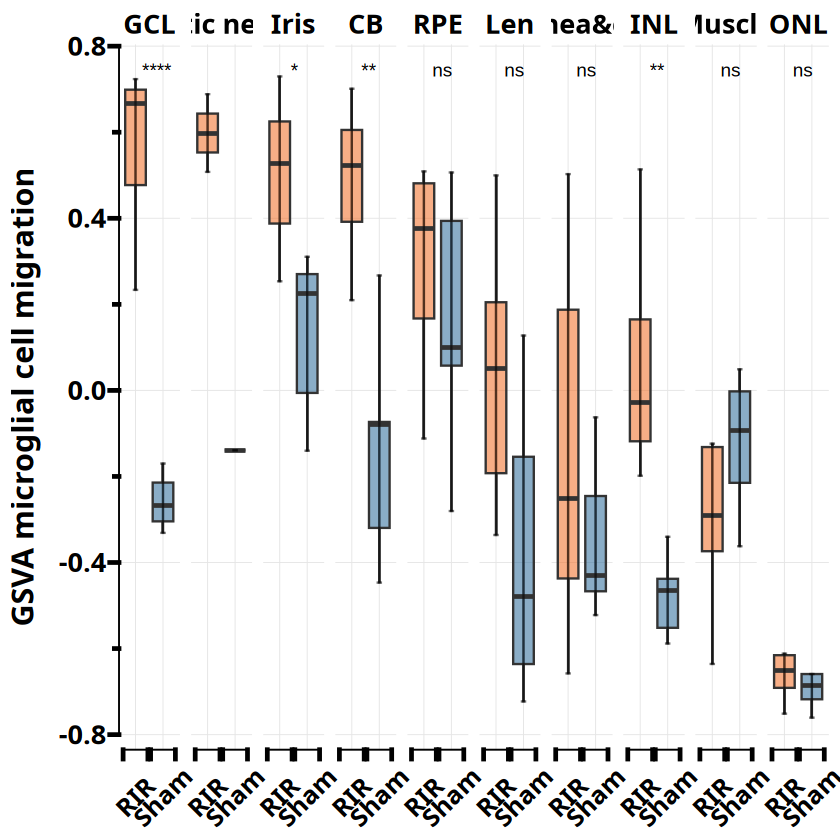

In [297]:
i <- "microglial cell migration"
p<-ggplot(mer,aes(x=group,y=mer[,i],fill=group,alpha=1))+
stat_boxplot(geom="errorbar",position=position_dodge(width=0.4),width=0.1)+
geom_boxplot(position=position_dodge(width=0.6),outlier.shape=NA)+
facet_wrap(.~area,scales="free_x",nrow=1)+
scale_x_discrete(guide="prism_bracket")+scale_fill_manual(values = cols4)+
scale_y_continuous(guide="prism_offset_minor")+
stat_compare_means(aes(group = group),
                    label="p.signif",method = "t.test",label.x = 1.45)+
labs(x=NULL,y=paste0("GSVA ",i))+mytheme+
stat_boxplot(geom = "errorbar",width=0.2)#+scale_y_continuous(limits = c(0, 0.1)) 
p
ggsave(paste0(i,"_eye_area_RIR_vs_Blank_boxplot.pdf"),p,width = 8,height = 6)

In [260]:
mer <- bulk@meta.data

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


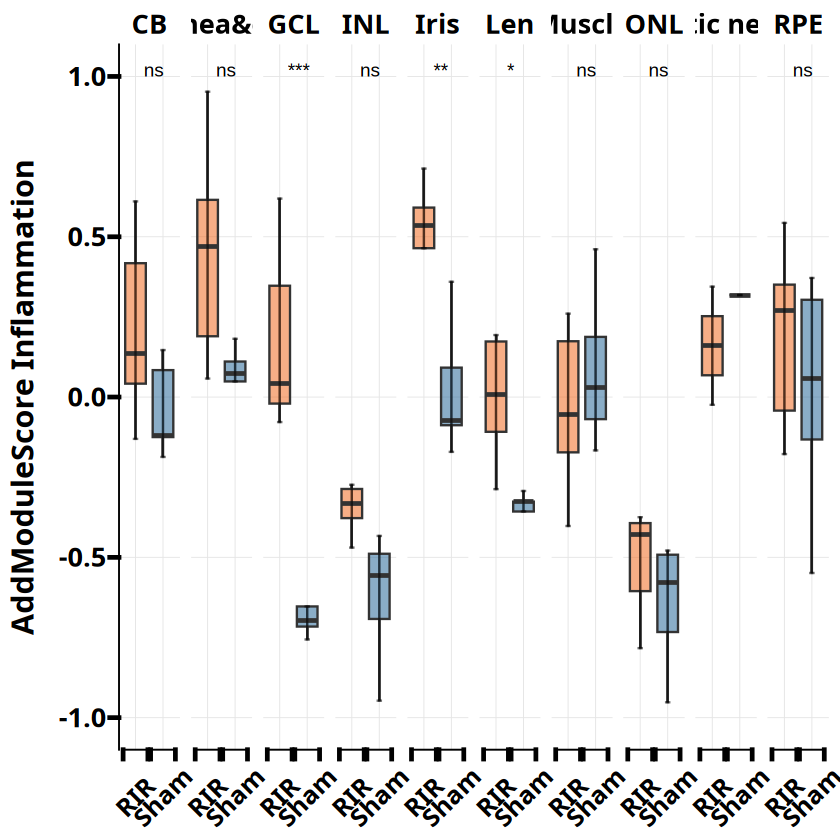

In [261]:
i <- "Inflammation"
p<-ggplot(mer,aes(x=group,y=mer[,i],fill=group,alpha=0.9))+
stat_boxplot(geom="errorbar",position=position_dodge(width=0.4),width=0.1)+
geom_boxplot(position=position_dodge(width=0.6),outlier.shape=NA)+
facet_wrap(.~area,scales="free_x",nrow=1)+
scale_x_discrete(guide="prism_bracket")+scale_fill_manual(values = cols4)+
scale_y_continuous(guide="prism_offset_minor")+
stat_compare_means(aes(group = group),
                    label="p.signif",method = "t.test",label.x = 1.45)+
labs(x=NULL,y=paste0("AddModuleScore ",i))+mytheme+
stat_boxplot(geom = "errorbar",width=0.2)+scale_y_continuous(limits = c(-1,1)) 
p